In [8]:
import pandas as pd
import os

folder_path = 'D:/Project/Github/stocks-analysis/stocks_data'  # your folder path
all_data = []

for file in os.listdir(folder_path):
    if file.endswith('.csv'):
        stock_code = file.replace('.csv', '')
        
        df = pd.read_csv(os.path.join(folder_path, file))
        
        # Convert date column
        df['date'] = pd.to_datetime(df['date'])
        
        # Keep only date + avg_price
        df = df[['date', 'avg_price']]
        
        # Rename column to stock code
        df = df.rename(columns={'avg_price': stock_code})
        
        # Set index
        df = df.set_index('date')
        
        all_data.append(df)

In [11]:
# Combine all stocks into one dataframe
combined_df = pd.concat(all_data, axis=1)
combined_df = combined_df.sort_index()
combined_df.head()

C:\Users\aldo.azali.QUADRACENTRUM\AppData\Local\Temp\ipykernel_13268\9199960.py:2: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  combined_df = pd.concat(all_data, axis=1)


,ADRO,AKRA,ANTM,ASII,BBCA,BBNI,BBRI,BJBR,BJTM,BMRI,...,KLBF,MDKA,MEDC,MTEL,PGAS,PTBA,SIDO,TLKM,TOWR,UNTR
date,,,,,,,,,,,,,,,,,,,,,
2023-01-02,3610.0,1391.25,1988.75,5693.75,NaN,4596.875,NaN,1348.75,708.75,NaN,...,2080.0,4122.5,1056.25,775.00,1752.50,3700.0,750.0,3775.0,1121.25,25962.5
2023-01-03,3550.0,1373.75,1993.75,5662.50,NaN,4615.625,NaN,1351.25,710.00,NaN,...,2090.0,4227.5,1101.25,751.25,1741.25,3710.0,745.0,3827.5,1156.25,25862.5
2023-01-04,3425.0,1323.75,2045.00,5662.50,NaN,4612.500,NaN,1352.50,711.25,NaN,...,2107.5,4337.5,1088.75,732.50,1696.25,3675.0,750.0,3832.5,1167.50,25050.0
2023-01-05,3175.0,1252.50,1992.50,5525.00,NaN,4515.625,NaN,1343.75,708.75,NaN,...,2077.5,4267.5,1032.50,716.25,1606.25,3512.5,747.5,3777.5,1151.25,24300.0
2023-01-06,3127.5,1251.25,1962.50,5431.25,NaN,4475.000,NaN,1340.00,705.00,NaN,...,2047.5,4215.0,1015.00,712.50,1576.25,3427.5,742.5,3735.0,1143.75,24875.0


In [12]:
# Forward fill (common in financial data)
combined_df = combined_df.ffill()

# Or drop rows with too many NaN
combined_df = combined_df.dropna()

In [21]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# plot_df = combined_df.loc['2024-01-01':'2025-12-31']

In [28]:
returns = combined_df.pct_change().dropna()
corr_matrix = returns.corr()

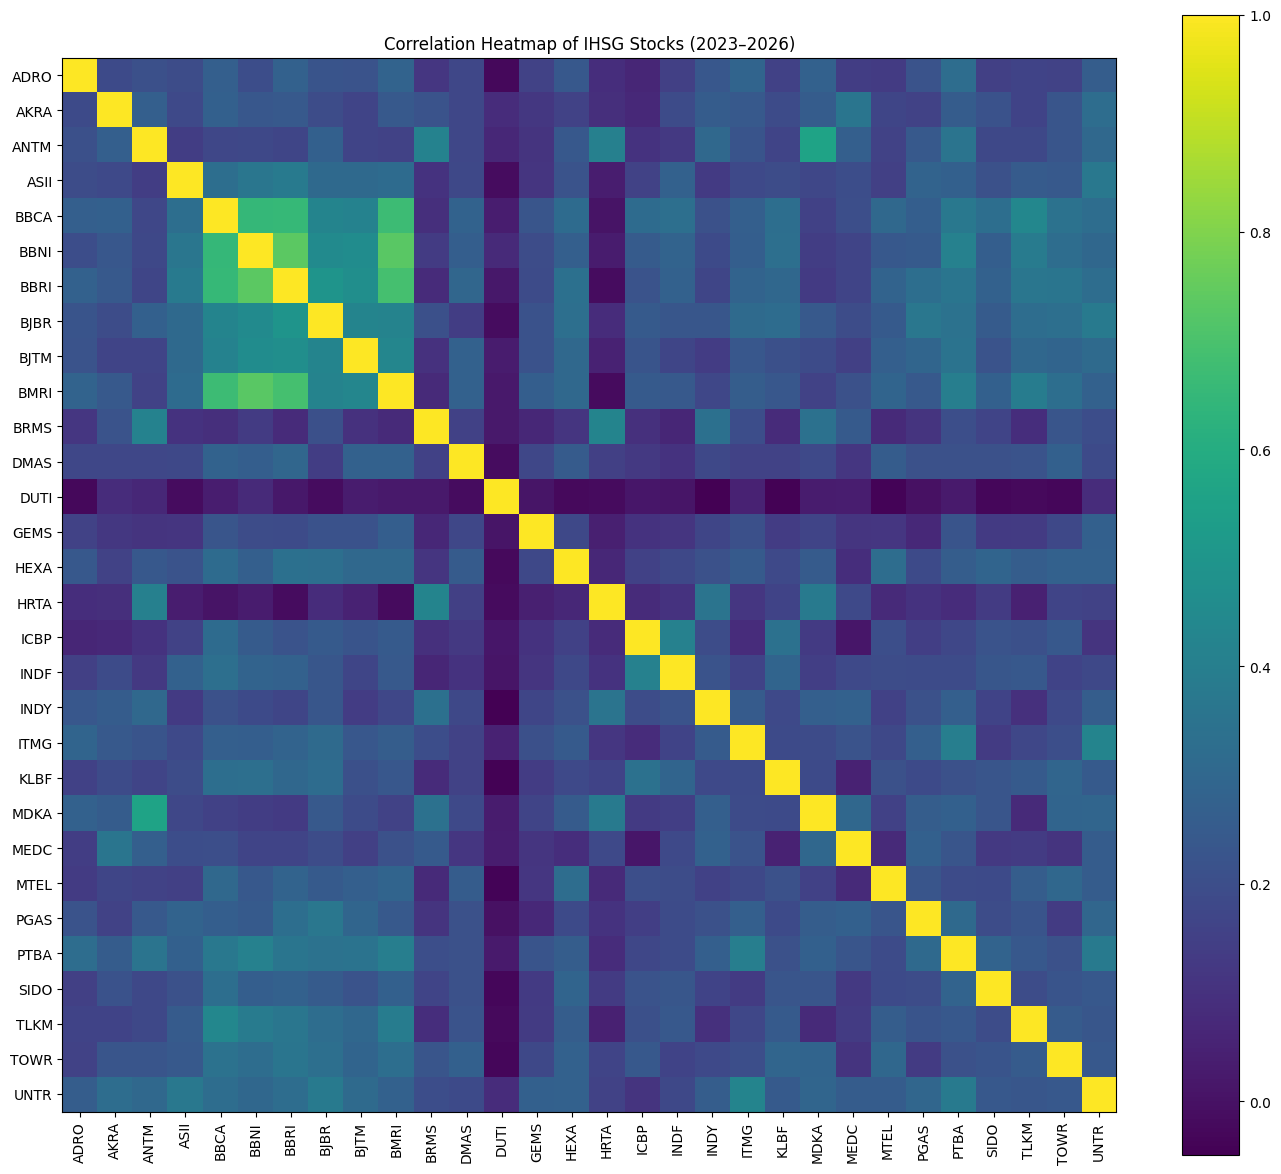

In [29]:
# --- STEP 4: Plot heatmap ---
plt.figure(figsize=(14, 12))
heatmap = plt.imshow(corr_matrix)

# Add colorbar
plt.colorbar()
# Add labels
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)
# Title
plt.title("Correlation Heatmap of IHSG Stocks (2023–2026)")

plt.tight_layout()
plt.show()

In [31]:
strong_corr = corr_matrix[(corr_matrix > 0.6) | (corr_matrix < -0.6)]
print(strong_corr)

      ADRO  AKRA  ANTM  ASII      BBCA      BBNI      BBRI  BJBR  BJTM  \
ADRO   1.0   NaN   NaN   NaN       NaN       NaN       NaN   NaN   NaN   
AKRA   NaN   1.0   NaN   NaN       NaN       NaN       NaN   NaN   NaN   
ANTM   NaN   NaN   1.0   NaN       NaN       NaN       NaN   NaN   NaN   
ASII   NaN   NaN   NaN   1.0       NaN       NaN       NaN   NaN   NaN   
BBCA   NaN   NaN   NaN   NaN  1.000000  0.651526  0.654260   NaN   NaN   
BBNI   NaN   NaN   NaN   NaN  0.651526  1.000000  0.736481   NaN   NaN   
BBRI   NaN   NaN   NaN   NaN  0.654260  0.736481  1.000000   NaN   NaN   
BJBR   NaN   NaN   NaN   NaN       NaN       NaN       NaN   1.0   NaN   
BJTM   NaN   NaN   NaN   NaN       NaN       NaN       NaN   NaN   1.0   
BMRI   NaN   NaN   NaN   NaN  0.671093  0.730331  0.688972   NaN   NaN   
BRMS   NaN   NaN   NaN   NaN       NaN       NaN       NaN   NaN   NaN   
DMAS   NaN   NaN   NaN   NaN       NaN       NaN       NaN   NaN   NaN   
DUTI   NaN   NaN   NaN   NaN       NaN